In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../ml/data/processed/combined.csv")
print(df.shape)
df.head()

(57653, 19)


,timestamp,player_x,player_y,player_z,enemy_x,enemy_y,enemy_z,aim_yaw,aim_pitch,mouse_dx,mouse_dy,fov_to_target,snap_delta,time_to_kill,is_firing,enemy_killed,label,session_id,session_type
0,0.652,0.0,0.770651,0.0,-3.5,2.5,-6.0,0.0,0.0,0.0,0.0,30.789202,0.454973,-1.0,0,0,clean,cheat_001,cheat
1,0.652,0.0,0.805727,0.0,-3.5,2.5,-6.0,0.0,0.0,0.0,0.0,30.739908,0.049293,-1.0,0,0,clean,cheat_001,cheat
2,0.652,0.0,0.810273,0.0,-3.5,2.5,-6.0,0.0,0.0,0.0,0.0,30.733693,0.006215,-1.0,0,0,clean,cheat_001,cheat
3,0.652,0.0,0.810273,0.0,-3.5,2.5,-6.0,0.0,0.0,0.0,0.0,30.733693,0.000000,-1.0,0,0,clean,cheat_001,cheat
4,0.652,0.0,0.810273,0.0,-3.5,2.5,-6.0,0.0,0.0,0.0,0.0,30.733693,0.000000,-1.0,0,0,clean,cheat_001,cheat


Text(0.5, 1.0, 'snap_delta distribution by label')

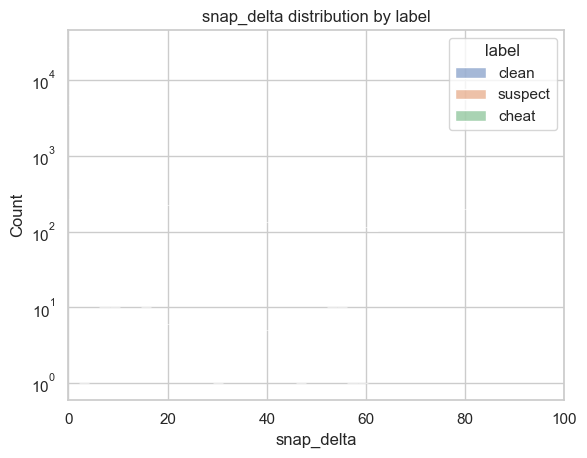

In [2]:
sns.histplot(data=df, x="snap_delta", hue="label", bins=80, log_scale=(False, True))
plt.xlim(0, 100)
plt.title("snap_delta distribution by label")

Text(0.5, 1.0, '30-frame rolling std of mouse_dx by label')

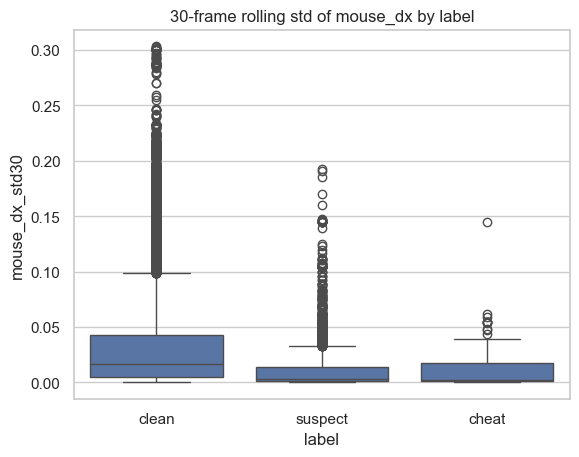

In [3]:
df["mouse_dx_std30"] = df.groupby("session_id")["mouse_dx"].transform(lambda x: x.rolling(30).std())
sns.boxplot(data=df.dropna(), x="label", y="mouse_dx_std30")
plt.title("30-frame rolling std of mouse_dx by label")

Text(0.5, 1.0, 'Feature correlations')

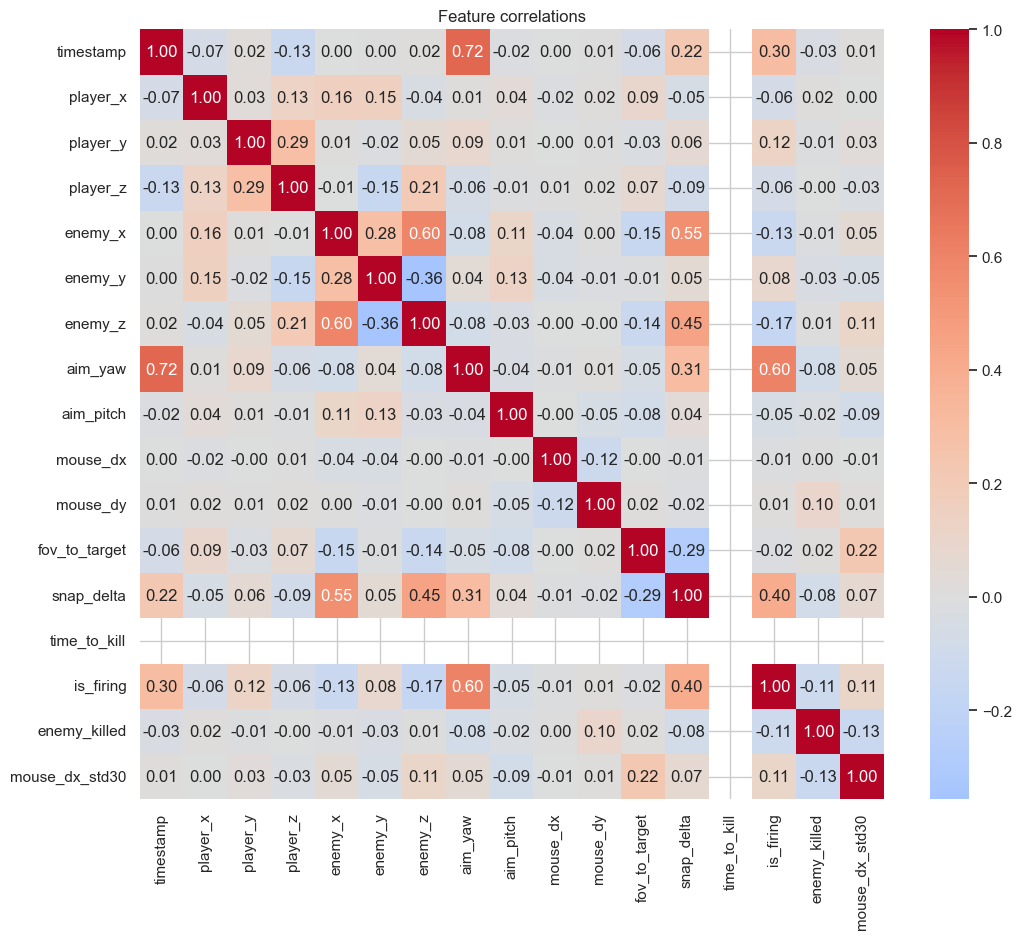

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlations")